In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [23]:
os.chdir(os.path.expanduser("~"))
v2 = pd.read_csv("pycrac2_test/tests/timings_test.tsv", sep="\t")
v1 = pd.read_csv("pycrac/tests/timings.tsv", sep="\t") 
print(v1)
print(v2)

                                                 test  \
0                        range 300 and deletions only   
1    same as above but counting hits for introns only   
2   same as above but now counting hits in exons only   
3                                 # pyClusterReads...   
4   counting overlap between clusters and genomic ...   
5                                  with range setting   
6                    with annotation = protein_coding   
7                    with annotation = protein_coding   
8                                with all annotations   
9                              with --binoverlap flag   
10                              with --outputall flag   
11                                    with genes list   
12          with genes list and removal of duplicates   
13                        with chromosome coordinates   
14  with chromosome coordinates and removal of dup...   
15                        with chromosome coordinates   
16             with genes list 

In [24]:
labels = [
    "pyNormalizeIntervalLengths --fixed 20",
    "pyNormalizeIntervalLengths --min 20",
    "pyNormalizeIntervalLengths --addboth 20",
    "pyNormalizeIntervalLengths --addleft 20",
    "pyNormalizeIntervalLengths --addright 20",
]
m1 = v1["script"].eq("pyNormalizeIntervalLengths.py")
m2 = v2["script"].eq("pyNormalizeIntervalLengths.py")

v1.loc[m1, "test"] = labels
v2.loc[m2, "test"] = labels

In [28]:
df = v1.merge(
    v2,
    on=["script", "test"],
    how="outer",
    suffixes=("_v1", "_v2"))

df = df.dropna(axis=0)
df["test"] = df["test"].str.replace(r"[#\.]", "", regex=True)
df["test"] = df["test"].str.replace(r"py$", "", regex=True)
df.to_csv("test2_timings.tsv", sep="\t")
df
df_plot_list = ["pyFastqJoiner.py",
"pyFastqDuplicateRemover.py",
"pyReadCounters.py",
"pyPileup.py",
"pyReadAligner.py",
"pyClusterReads.py",
"pyCalculateFDRs.py",
"pyGTF2bedGraph.py",
"pyGTF2sgr.py",
"pyFilterGTF.py",
"pyMotif.py",
"pyBinCollector.py",
"pyCalculateMutationFrequencies.py",
"pyNormalizeIntervalLengths.py",
"pyFastqSplitter.py"]
df = df[df["script"].isin(df_plot_list)]

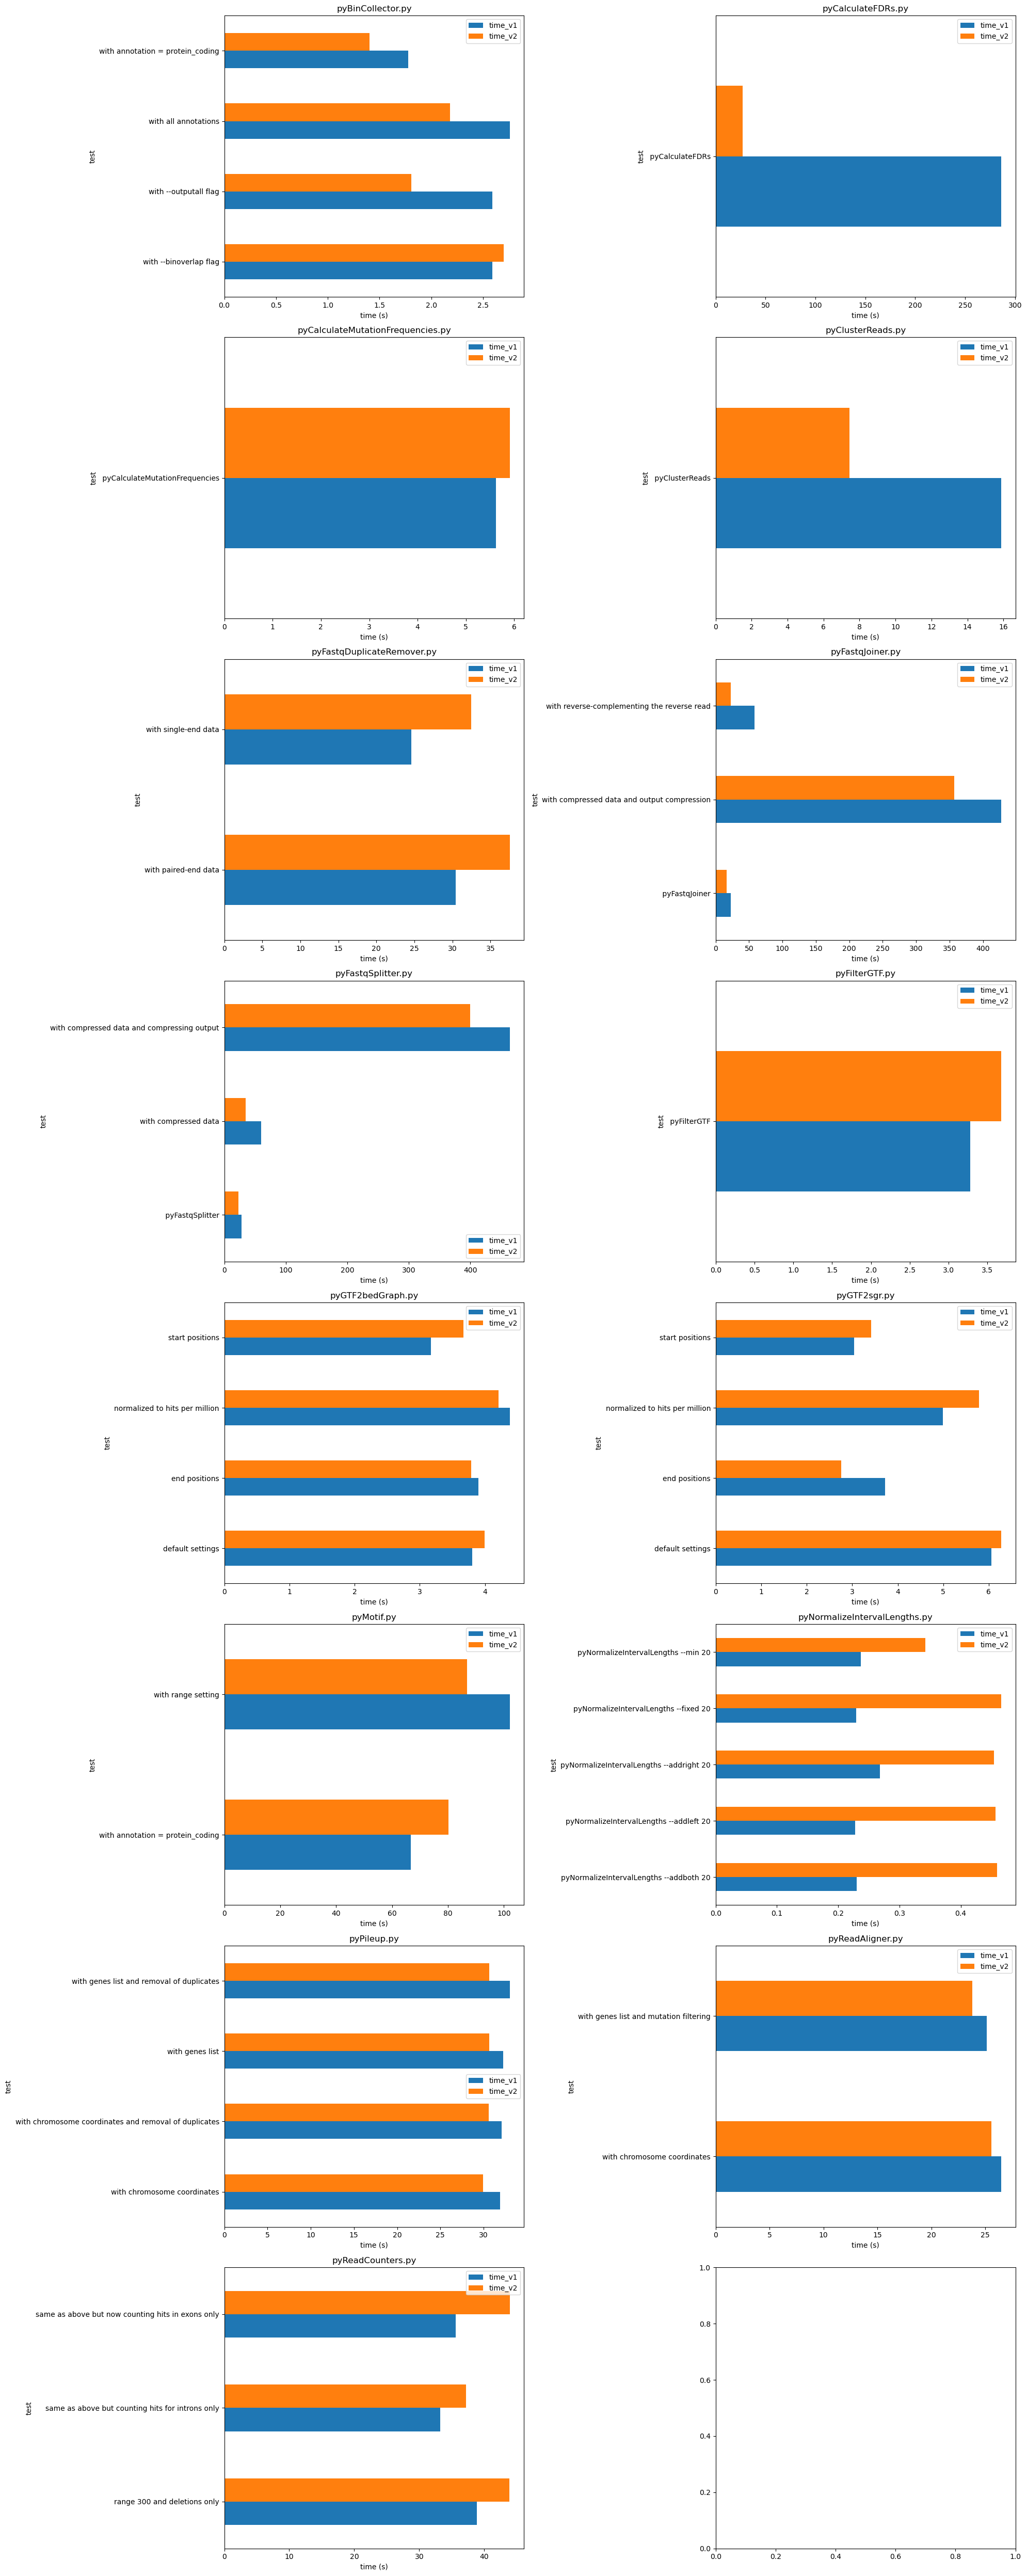

In [34]:
fig, ax = plt.subplots(8, 2, figsize=(20, 50))
ax = ax.ravel()
scripts={}
for i, (script, subplt) in enumerate(df.groupby("script")):
    subplt.plot(
        x= "test",
        y=["time_v1", "time_v2"],
        kind="barh",
        ax=ax[i]
    )
    ax[i].set_title(script)
    ax[i].set_xlabel("time (s)")
    #fold change calculation
    ave_fc = subplt["time_v1"].mean()/subplt["time_v2"].mean()
    if script not in scripts: 
        scripts[script] = ave_fc
plt.tight_layout()
plt.savefig("pycrac_1v2_large_plot.pdf")
plt.show()

pyBinCollector.py 1.20061804697157
pyCalculateFDRs.py 10.675847141364383
pyCalculateMutationFrequencies.py 0.9515746698272943
pyClusterReads.py 2.135727737422653
pyFastqDuplicateRemover.py 0.7858408597233336
pyFastqJoiner.py 1.279826764789616
pyFastqSplitter.py 1.206764188970595
pyFilterGTF.py 0.8922742110990206
pyGTF2bedGraph.py 0.9745194456861869
pyGTF2sgr.py 0.9771256171146461
pyMotif.py 1.0102214344738385
pyNormalizeIntervalLengths.py 0.5472910927456383
pyPileup.py 1.0613276857027936
pyReadAligner.py 1.0460017022656345
pyReadCounters.py 0.8609946890197082


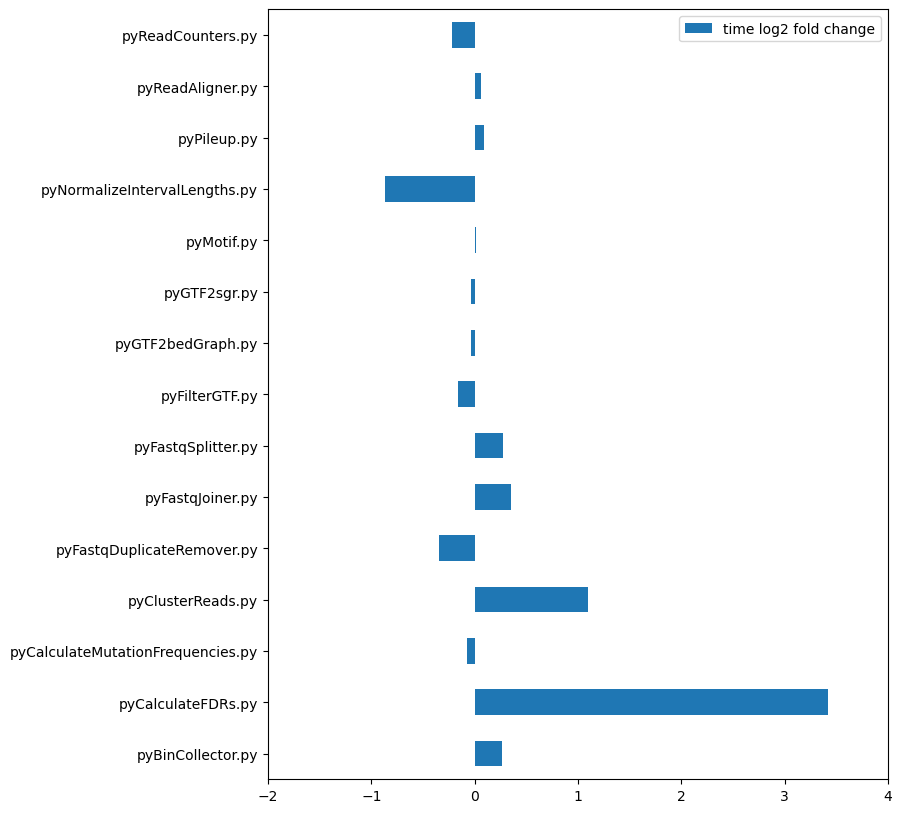

In [33]:
for key, value in scripts.items():
    print(key, value)

df_fc = pd.DataFrame([scripts])

df_fc = np.log2(df_fc.T)
df_fc = df_fc.rename(columns={0:"time log2 fold change"})

ax = df_fc.plot(
    kind="barh",
    figsize=(8, 10)
)
ax.set_xlim(-2, 4)
plt.savefig("pycrac_1v2_lfc_large_plot.pdf")
plt.show()


In [11]:
!jupyter nbconvert --to python plot.ipynb